In [30]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
df = pd.read_csv('../data/BVBRC_genome_amr.csv', index_col=0)
df

C:\Users\Mr_Nnobody\AppData\Local\Temp\ipykernel_18912\1929598575.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/BVBRC_genome_amr.csv', index_col=0)


,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,Laboratory Typing Method Version,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
Taxon ID,,,,,,,,,,,,,,,,,,,,
562,562.144628,Escherichia coli 10,ceftriaxone,NaN,<=0.25,<=,0.25,mg/L,MIC,NaN,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
562,562.569100,Escherichia coli CVM N36113PS,trimethoprim/sulfamethoxazole,NaN,<=0.12,<=,0.12,mg/L,Broth dilution,NaN,Sensititre,Thermo Fisher Scientific,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,26142410,26142410
562,562.144245,Escherichia coli ERR7221502,meropenem,Susceptible,NaN,NaN,NaN,NaN,Broth dilution,NaN,VITEK 2,BioMerieux,EUCAST,2016.0,NaN,NaN,NaN,Laboratory Method,NaN,36916881
562,562.100003,Escherichia coli c1b4da3e-7bb9-11e9-a8d3-68b59...,trimethoprim/sulfamethoxazole,Susceptible,NaN,NaN,NaN,NaN,Disk diffusion,NaN,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
562,562.143892,Escherichia coli JBDIABB-19-0096,piperacillin/tazobactam,NaN,<=4,<=,4,mg/L,MIC,NaN,NaN,Beckman Coulter Inc,CLSI,2021.0,NaN,NaN,NaN,Laboratory Method,NaN,38052776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562.144668,Escherichia coli 38,amoxicillin/clavulanic acid,NaN,8,NaN,8,mg/L,MIC,NaN,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
562,562.236000,Escherichia coli O17:H18 strain ECO1306,gentamicin,NaN,0.5,NaN,0.5,mg/L,MIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,38219757
562,562.990490,Escherichia coli c4faf2ce-7bb8-11e9-a8d3-68b59...,tigecycline,Susceptible,NaN,NaN,NaN,NaN,Disk diffusion,NaN,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242917 entries, 562 to 562
Data columns (total 20 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Genome ID                         242917 non-null  float64
 1   Genome Name                       242917 non-null  object 
 2   Antibiotic                        242917 non-null  object 
 3   Resistant Phenotype               93629 non-null   object 
 4   Measurement                       171962 non-null  object 
 5   Measurement Sign                  89387 non-null   object 
 6   Measurement Value                 171974 non-null  object 
 7   Measurement Unit                  171963 non-null  object 
 8   Laboratory Typing Method          242917 non-null  object 
 9   Laboratory Typing Method Version  162 non-null     object 
 10  Laboratory Typing Platform        41663 non-null   object 
 11  Vendor                            118539 non-null  object 

In [4]:
# Check the distribution of the target variable
df['Resistant Phenotype'].value_counts()

Resistant Phenotype
Susceptible                   70815
Resistant                     20789
Intermediate                   2015
Nonsusceptible                    6
Susceptible-dose dependent        4
Name: count, dtype: int64

In [5]:
# Check antibiotic distribution and count unique antibiotics
df['Antibiotic'].value_counts()

Antibiotic
ciprofloxacin              15895
ceftazidime                15238
piperacillin/tazobactam    14052
cefotaxime                 13890
gentamicin                 13464
                           ...  
teicoplanin                    1
linezolid                      1
vancomycin                     1
cephalexin                     1
metronidazole                  1
Name: count, Length: 96, dtype: int64

In [6]:
len(df.Antibiotic.unique())

96

In [19]:
len(df['Genome Name'].unique())

12743

## Merge Data

Merge Phonotypic and Genome data together on Genome ID and Genome Name such that it keeps corresponding entries from each dataset

In [14]:
# getting genome data
genome_data = pd.read_csv('../data/BVBRC_genome (1).csv', index_col=0)


# right join to combine both dataframes on the genome id
combined_df = pd.merge(genome_data, df, on=['Genome ID','Genome Name'], how='right')
combined_df

C:\Users\Mr_Nnobody\AppData\Local\Temp\ipykernel_18912\582542800.py:2: DtypeWarning: Columns (17,33,34,37,83,84) have mixed types. Specify dtype option on import or set low_memory=False.
  genome_data = pd.read_csv('../data/BVBRC_genome (1).csv', index_col=0)


,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
0,562.144628,Escherichia coli 10,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
1,562.569100,Escherichia coli CVM N36113PS,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,Sensititre,Thermo Fisher Scientific,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,26142410,26142410
2,562.144245,Escherichia coli ERR7221502,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,VITEK 2,BioMerieux,EUCAST,2016.0,NaN,NaN,NaN,Laboratory Method,NaN,36916881
3,562.100003,Escherichia coli c1b4da3e-7bb9-11e9-a8d3-68b59...,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
4,562.143892,Escherichia coli JBDIABB-19-0096,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,Beckman Coulter Inc,CLSI,2021.0,NaN,NaN,NaN,Laboratory Method,NaN,38052776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242912,562.144668,Escherichia coli 38,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
242913,562.236000,Escherichia coli O17:H18 strain ECO1306,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,38219757
242914,562.990490,Escherichia coli c4faf2ce-7bb8-11e9-a8d3-68b59...,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
242915,562.978750,Escherichia coli 1119ae66-7bb9-11e9-a8d3-68b59...,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,38219757


In [20]:
len(combined_df['Genome Name'].unique())

12743

## AMR Matrix Transformation
We will now transform the data so that:
1. Each **Genome** is a row.
2. Each **Antibiotic** is a column.
3. The values are encoded: **Susceptible (0), Intermediate (1), Resistant (2), Nonsusceptible(2)**.


In [ ]:
# Map Phenotypes to Numbers
phenotype_map = {
    'Susceptible': 0,
    'Intermediate': 1,
    'Resistant': 2,
    'Nonsusceptible': 2, # Treat NonSusceptible as Resistant for simplicity
}

# Filter out rows where 'Resistant Phenotype' is missing or not in our map
clean_df = combined_df[combined_df['Resistant Phenotype'].isin(phenotype_map.keys())].copy()
clean_df['Phenotype_Code'] = clean_df['Resistant Phenotype'].map(phenotype_map)
print("Unique antibiotics after filtering:", len(clean_df.Antibiotic.unique()))
print("Unique genomes after filtering:", len(clean_df['Genome Name'].unique()))

# Pivot the table indexing with Genome Name
amr_matrix = clean_df.pivot_table(
    index=['Genome ID', 'Genome Name'],
    columns='Antibiotic',
    values='Phenotype_Code',
    aggfunc='max' # If there are duplicates, take the higher resistance (worst-case scenario)
)

# Extract accession metadata from duplicate-free genome data
# Keep index names explicit so `reset_index()` adds Genome ID and Genome Name as columns
amr_matrix.index = amr_matrix.index.set_names(['Genome ID', 'Genome Name'])
accession_cols = ['BioProject Accession', 'BioSample Accession', 'Assembly Accession', 'SRA Accession', 'GenBank Accessions']
accession_map = combined_df.drop_duplicates(subset=['Genome Name']).set_index('Genome Name')[accession_cols]

# Map the accessions back and insert them as the first columns
genome_names = amr_matrix.index.get_level_values('Genome Name')
for i, col in enumerate(accession_cols):
    amr_matrix.insert(i, col, genome_names.map(accession_map[col]))

amr_matrix = amr_matrix.reset_index()
amr_matrix


Unique antibiotics after filtering: 78
Unique genomes after filtering: 7884


IndexError: list index out of range


## Cleaning Antibiotics

Removing antibiotics which have more missing values or just a few actual Phenotypic label



In [48]:
# checking for missing values
missing_values = amr_matrix.isnull().sum().sort_values()
print("Missing values per antibiotic:\n", missing_values, )

Missing values per antibiotic:
 Antibiotic
gentamicin                      279
ciprofloxacin                   390
SRA Accession                   609
ceftazidime                     625
cefotaxime                     1233
                               ... 
teicoplanin                    7883
sulbactam                      7883
cephalexin                     7883
ceftazidime/clavulanic acid    7883
vancomycin                     7883
Length: 83, dtype: int64


In [49]:
# checking for missing values in Accession columns
for col in accession_cols:
    print(f"Missing values in {col}: {amr_matrix[col].isnull().sum()}") 

Missing values in BioProject Accession: 4996
Missing values in BioSample Accession: 4335
Missing values in Assembly Accession: 7237
Missing values in SRA Accession: 609
Missing values in GenBank Accessions: 7242


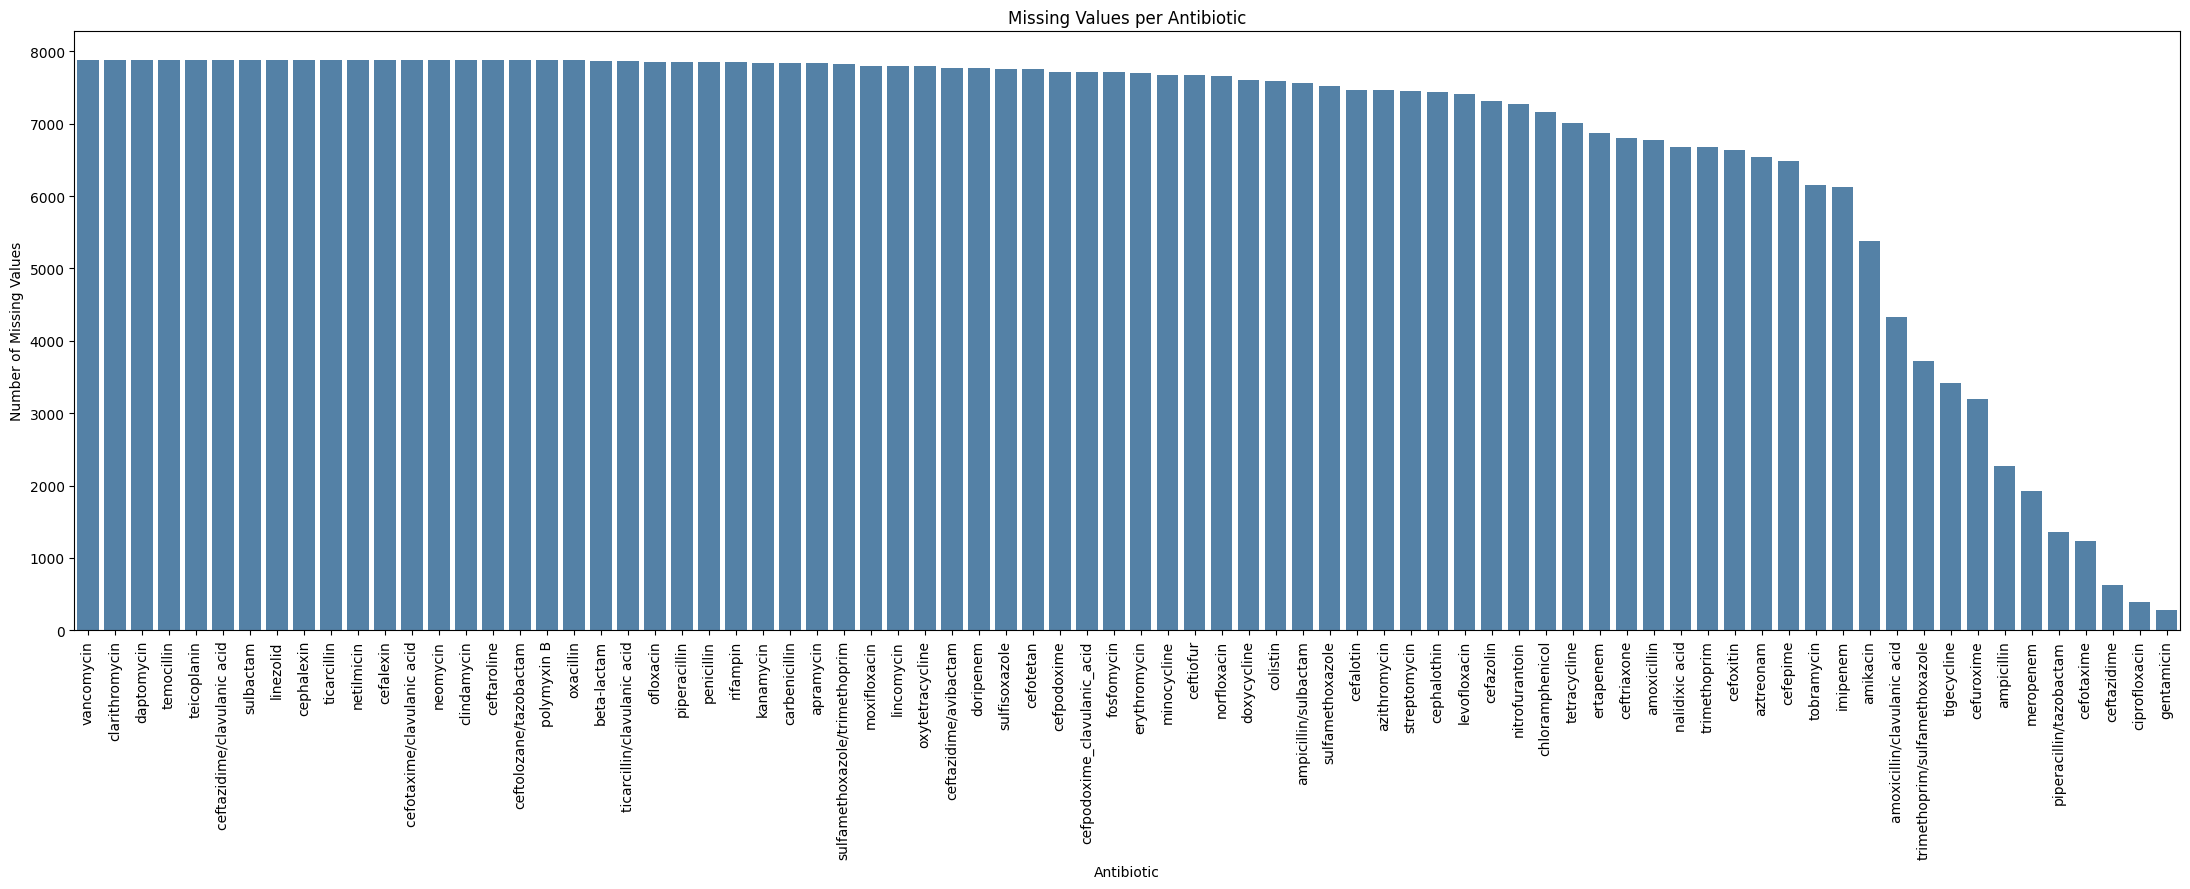

In [39]:
# count plot of missing values per antibiotics
missing_df = missing_values.sort_values(ascending=False).reset_index()
missing_df.columns = ['Antibiotic', 'Missing_Count']

plt.figure(figsize=(22, 9))
sns.barplot(data=missing_df, x='Antibiotic', y='Missing_Count', color='steelblue')
plt.xticks(rotation=90)
plt.title('Missing Values per Antibiotic')
plt.xlabel('Antibiotic')
plt.ylabel('Number of Missing Values')
plt.tight_layout()
plt.show()


In [40]:
# drop antibiotics with more than 50% missing values
threshold = len(amr_matrix) * 0.5
amr_matrix = amr_matrix.loc[:, ~(amr_matrix.isnull().sum() > threshold)]
amr_matrix


Antibiotic,ampicillin,cefotaxime,ceftazidime,cefuroxime,ciprofloxacin,gentamicin,meropenem,piperacillin/tazobactam,tigecycline,trimethoprim/sulfamethoxazole
Genome Name,,,,,,,,,,
Escherichia coli 001-E1-DxU,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
Escherichia coli 001-E1-S04,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
Escherichia coli 001-E1-S06,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
Escherichia coli 00116690-7bb9-11e9-a8d3-68b59976a384,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0
Escherichia coli 002-E1-DxU,2.0,NaN,2.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
Escherichia coli strain WU40,2.0,NaN,2.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
Escherichia coli strain WU43,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
Escherichia coli strain WU44,2.0,NaN,2.0,NaN,2.0,0.0,0.0,NaN,NaN,0.0
